<a href="https://colab.research.google.com/github/sujitx-vs/Deep-Neural-Networks---PGCP_AI/blob/main/DNN_Basics_Syntaxes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Syntax
- Model Creation
- Model Compilation
- Model Training

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error # regression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix # classification

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

##`Regression`

In [ ]:
|# RegressionModel Creation
model = keras.Sequential(
    [
        layers.Input(shape=(X_train.shape[1],)),

        layers.Dense(128,activation='relu'),
        layers.Dense(64,activation='relu'),
        layers.Dense(32,activation='relu'),
        layers.Dense(16,activation='relu'),
        layers.Dense(1,activation='linear')
    ]
)

`Regression with BatchNorm and Dropout`

In [ ]:
# Regression with BatchNorm and Dropout
model = keras.Sequential(
    [
        layers.Dense(128,activation='relu',input_shape=(X_train.shape[1],)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64,activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(32,activation='relu'),

        layers.Dense(1,activation='linear')
    ]
)

`regression model compile`

In [ ]:
# Regression Model Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

`EarlyStopping`

In [ ]:
# Callback Initialisation
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True,verbose =1),
]

Sample Data.

In [ ]:
from keras.datasets import boston_housing

(X_train,Y_train),(X_test,Y_test) = boston_housing.load_data()

`Model Training`

In [ ]:
# Model Training

history = model.fit(
    X_train,Y_train,
    epochs = 200,
    batch_size =32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 52.8447 - mae: 5.3237 - val_loss: 55.3818 - val_mae: 5.0534
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 58.9073 - mae: 5.7334 - val_loss: 53.9937 - val_mae: 5.0509
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 58.1348 - mae: 5.4019 - val_loss: 50.9769 - val_mae: 4.8567
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 45.1575 - mae: 4.9279 - val_loss: 50.5854 - val_mae: 4.8289
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 53.0685 - mae: 5.3515 - val_loss: 51.2711 - val_mae: 4.8013
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 59.6990 - mae: 5.5303 - val_loss: 52.8633 - val_mae: 4.6895
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 48.3750 - mae: 5.0924 - val_loss: 53.0451 - val_mae: 4.5777
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 53.9425 - mae: 5.2032 - val_loss: 49.9235 - val_mae: 4.4113
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0

`Evaluvation`

In [ ]:
# Regression Evaluvation
Y_pred = model.predict(X_test)

mae = mean_absolute_error(Y_test,Y_pred)
rmse = root_mean_squared_error(Y_test,Y_pred)
r2 = r2_score(Y_test,Y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
MAE: 4.457117757610247
RMSE: 6.1423765289192485
R2: 0.546767838177928


`Plotting the Graphs`

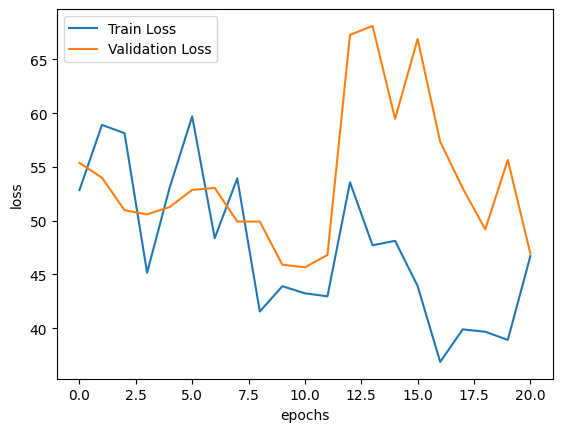

In [ ]:
# Plotting loss
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label ='Validation Loss')
plt.legend()
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

In [ ]:
his = pd.DataFrame(history.history)
his

,loss,mae,val_loss,val_mae
0,52.844681,5.323657,55.381783,5.053371
1,58.907253,5.733361,53.993706,5.050880
2,58.134850,5.401899,50.976925,4.856658
3,45.157467,4.927928,50.585449,4.828943
4,53.068535,5.351453,51.271111,4.801263
5,59.699001,5.530327,52.863300,4.689510
6,48.375000,5.092382,53.045120,4.577744
7,53.942471,5.203177,49.923519,4.411278
8,41.554272,4.561484,49.919823,4.399910
9,43.911076,4.692070,45.907307,4.222647


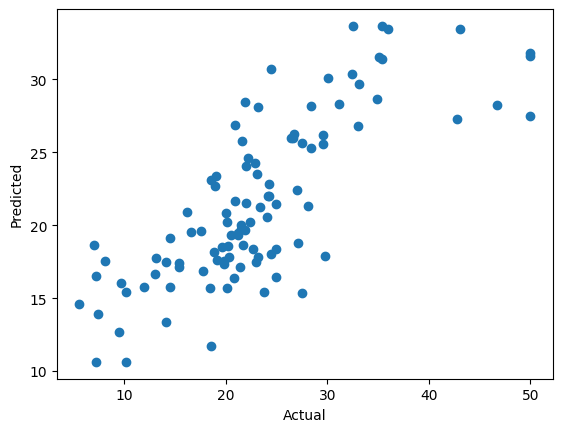

In [ ]:
# plotting Actual vs Predicted.
plt.scatter(Y_test,Y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## `Classification`

- `Binary`

Sample Data

In [ ]:
from sklearn.datasets import make_classification
data = make_classification(n_samples=1000,n_features=10,n_classes=2,random_state=42)
X_train,X_test,Y_train,Y_test = train_test_split(data[0],data[1],test_size=0.2,random_state=42)

`Binary Classification Model`

In [ ]:
# Binary Classification Model
bin_model = keras.Sequential(
    [
        layers.Input(shape=(X_train.shape[1],)),

        layers.Dense(32,activation='relu'),
        layers.Dense(16,activation='relu'),
        layers.Dense(1,activation='sigmoid')
    ]
)

In [ ]:
# Binary Classification Model with Dropout
bin_model = keras.Sequential(
    [
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dropout(0.2),
        layers.Dense(32,activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(16,activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1,activation='sigmoid')
    ]
)

`Binary Model Complie`

In [ ]:
# Binary Model Compile
bin_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
# Callback Initialisation
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True,verbose =1),
]

In [ ]:
bin_history = bin_model.fit(
    X_train,Y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8547 - loss: 0.3593 - val_accuracy: 0.8562 - val_loss: 0.3560
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8531 - loss: 0.3591 - val_accuracy: 0.8562 - val_loss: 0.3566
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8609 - loss: 0.3643 - val_accuracy: 0.8625 - val_loss: 0.3567
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8547 - loss: 0.3322 - val_accuracy: 0.8625 - val_loss: 0.3571
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8531 - loss: 0.3658 - val_accuracy: 0.8562 - val_loss: 0.3571
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8594 - loss: 0.3351 - val_accuracy: 0.8562 - val_loss: 0.3557
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8656 - loss: 0.3385 - val_accuracy: 0.8562 - val_loss: 0.3557
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8609 - loss: 0.3293 - val_accuracy: 0.85

`Evaluation of Binary Classification Model`

In [ ]:
# Binary Model Evaluvation
bin_loss, bin_acc = bin_model.evaluate(X_test,Y_test)

print(f"Binary Loss: {bin_loss}")
print(f"Binary Accuracy: {bin_acc}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8250 - loss: 0.3685 
Binary Loss: 0.36852458119392395
Binary Accuracy: 0.824999988079071


`Plotting Binary Classification Model`

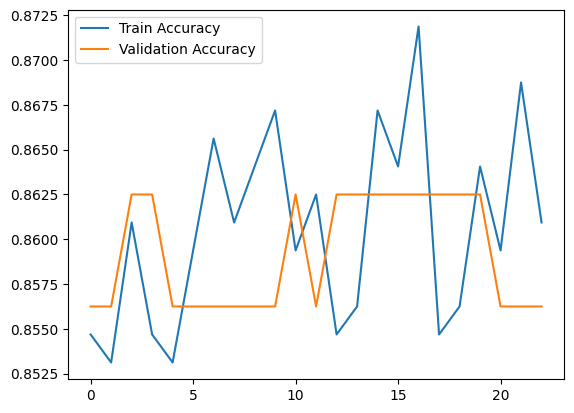

In [ ]:
# Binary Model Plots Accuraacy and Loss.
plt.plot(bin_history.history['accuracy'],label='Train Accuracy')
plt.plot(bin_history.history['val_accuracy'],label='Validation Accuracy')
# plt.plot(bin_history.history['loss'],label='Train Loss')
plt.legend()
plt.show()

`Multiclass Classification`

sample data

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
x, y = iris.data, iris.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

onehot encoding for categorical mmulticlass classification

In [ ]:
#OneHot keras
num_class = 3 # classes in the target column is 3.
y_train_oh = keras.utils.to_categorical(y_train, num_classes= num_class)
y_test_oh = keras.utils.to_categorical(y_test, num_classes=num_class)

`Multiclass model`

In [ ]:
# Multiclass Model
mul_model = keras.Sequential([
    layers.Dense(16,activation='relu',input_shape=(x_train.shape[1],)),
    layers.Dense(8,activation='relu'),
    layers.Dense(num_class,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


`Multiclass Compile`

In [ ]:
#Multiclass compile
mul_model.compile(
    optimizer='adam', # keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# early_stop
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
    )

`Multiclass Train`

In [ ]:
# Multiclass train
mul_history = mul_model.fit(
    x_train,y_train_oh,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9688 - loss: 0.0811 - val_accuracy: 1.0000 - val_loss: 0.0386
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9688 - loss: 0.0805 - val_accuracy: 1.0000 - val_loss: 0.0381
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9688 - loss: 0.0799 - val_accuracy: 1.0000 - val_loss: 0.0375
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9688 - loss: 0.0792 - val_accuracy: 1.0000 - val_loss: 0.0370
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9688 - loss: 0.0790 - val_accuracy: 1.0000 - val_loss: 0.0365
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9688 - loss: 0.0780 - val_accuracy: 1.0000 - val_loss: 0.0359
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9688 - loss: 0.0777 - val_accuracy: 1.0000 - val_loss: 0.0354
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9688 - loss: 0.0770 - val_accuracy: 1.0000 - val_loss:

`Multiclass Evaluvation`

In [ ]:
# Multiclass Evaluvation
test_loss,test_acc = mul_model.evaluate(x_test,y_test_oh,verbose=0)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

Test Loss: 0.09372609108686447
Test Accuracy: 0.9666666388511658


`Multiclass Predict`

In [ ]:
# Multiclass predict
y_pred = mul_model.predict(x_test)
y_pred = np.argmax(y_pred,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


`Confusion Matrix`

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  0, 10]])

`New Sample Testing`

In [ ]:
# Multiclass New Sample pred
new_sample = np.array([[1.,2.1,5.4,0.2]])

new_scaled = scaler.transform(new_sample)

probs = mul_model.predict(new_scaled)[0]
probs = np.round(probs,3)
print(f"probability :{probs}")
pred_class = np.argmax(probs)
pred_name = iris.target_names[pred_class]
print(f"Predicted Class: {pred_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
probability :[0.022 0.028 0.949]
Predicted Class: virginica
